In [19]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Approximate method for counting tokens
print("using approximate token counting")
USE_TIKTOKEN = False

using approximate token counting


In [20]:
# Reading the dataset
df = pd.read_csv("data/GPT-matches.csv")

In [21]:
# Displaying information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14813 entries, 0 to 14812
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     14813 non-null  object
 1   model_a                14813 non-null  object
 2   model_b                14813 non-null  object
 3   winner                 14813 non-null  object
 4   evaluation_session_id  14813 non-null  object
 5   evaluation_order       14813 non-null  int64 
 6   conversation_a         14813 non-null  object
 7   conversation_b         14813 non-null  object
 8   full_conversation      14813 non-null  object
 9   conv_metadata          14813 non-null  object
 10  category_tag           14813 non-null  object
 11  language               14813 non-null  object
 12  is_code                14813 non-null  bool  
 13  timestamp              14813 non-null  object
 14  turns                  14813 non-null  int64 
 15  response_a         

In [22]:
# Printing column names of the dataset
print(df.columns)

Index(['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id',
       'evaluation_order', 'conversation_a', 'conversation_b',
       'full_conversation', 'conv_metadata', 'category_tag', 'language',
       'is_code', 'timestamp', 'turns', 'response_a', 'response_b',
       'user_prompt', 'gpt_in_a', 'gpt_in_b', 'gemini_in_a', 'gemini_in_b',
       'grok_in_a', 'grok_in_b', 'claude_in_a', 'claude_in_b'],
      dtype='object')


In [23]:
# Keep only relevant columns (ignore evaluation_order, turns as per requirements)
df = df[['id', 'model_a', 'model_b', 'winner', 'conversation_a', 'conversation_b', 'full_conversation', 
         'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp', 
         'response_a', 'response_b', 'user_prompt', 'gpt_in_a', 'gpt_in_b']]

# Display basic info
print(f"Total records: {len(df)}")
print(f"\nLanguages distribution:")
print(df['language'].value_counts())
print(f"\nOpenAI models in dataset:")
print(f"GPT in model_a: {df['gpt_in_a'].sum()}")
print(f"GPT in model_b: {df['gpt_in_b'].sum()}")
print(f"Total battles with GPT: {(df['gpt_in_a'] | df['gpt_in_b']).sum()}")

Total records: 14813

Languages distribution:
language
en     8204
und    1356
pl     1263
ru      861
zh      695
       ... 
be        1
bs        1
ln        1
ak        1
eu        1
Name: count, Length: 72, dtype: int64

OpenAI models in dataset:
GPT in model_a: 7394
GPT in model_b: 7419
Total battles with GPT: 14813


In [24]:
# Robust language detection implementation
from modules.detectLanguage import detectLanguage as _detectLanguage
from modules.detectLanguage import detectMultiLanguage as _detectMultiLanguage

def detect_language(text):
    """
    Detect the primary language of a text.
    Returns the language code (e.g., 'en', 'zh', 'fr') or 'unknown'.
    """
    if pd.isna(text) or text == '':
        return 'unknown'
    return _detectLanguage(text)

def detect_multi_language(text):
    """
    Detect if a text contains multiple languages.
    Returns a dictionary with multi-language status and language distribution.
    """
    if pd.isna(text) or text == '':
        return {
            'is_multi_language': False,
            'languages': [],
            'primary_language': 'unknown',
            'secondary_languages': []
        }
    return _detectMultiLanguage(text)

print("Language detection functions defined!")

Language detection functions defined!


In [ ]:
# Test and apply robust language detection to the dataset
print("=" * 60)
print("ROBUST LANGUAGE DETECTION ANALYSIS")
print("=" * 60)

# Apply language detection to key text columns
print("\nDetecting languages for user_prompt, response_a, and response_b...")
print("This may take a few minutes...")

# Detect primary language for each text column
text_columns = ['user_prompt', 'response_a', 'response_b']

for col in text_columns:
    if col in df.columns:
        print(f"\nProcessing {col}...")
        # Detect primary language (returns string directly)
        df[f'{col}_detected_lang'] = df[col].apply(detect_language)
        
        # Detect multi-language
        multi_lang_results = df[col].apply(detect_multi_language)
        df[f'{col}_is_multi_lang'] = multi_lang_results.apply(lambda x: x['is_multi_language'])
        df[f'{col}_primary_lang'] = multi_lang_results.apply(lambda x: x['primary_language'])
        df[f'{col}_secondary_langs'] = multi_lang_results.apply(lambda x: x['secondary_languages'])

print("\nLanguage detection complete!")

# Summary statistics
print("\n" + "=" * 60)
print("LANGUAGE DETECTION SUMMARY")
print("=" * 60)

for col in text_columns:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(f"  Detected languages: {df[f'{col}_detected_lang'].nunique()}")
        print(f"  Multi-language texts: {df[f'{col}_is_multi_lang'].sum()} ({df[f'{col}_is_multi_lang'].mean()*100:.1f}%)")
        
        # Top detected languages
        top_detected = df[f'{col}_detected_lang'].value_counts().head(5)
        print(f"  Top 5 detected languages:")
        for lang, count in top_detected.items():
            print(f"    {lang}: {count} ({count/len(df)*100:.1f}%)")

# Compare with original language column
print("\n" + "=" * 60)
print("COMPARISON WITH ORIGINAL LANGUAGE COLUMN")
print("=" * 60)

# Use response_a as the main comparison (or user_prompt)
comparison_col = 'response_a'
if comparison_col in df.columns:
    print(f"\nComparing detected language ({comparison_col}_detected_lang) with original 'language' column:")
    
    # Create comparison
    comparison_df = df[[comparison_col, 'language', f'{comparison_col}_detected_lang', 
                        f'{comparison_col}_is_multi_lang']].copy()
    
    # Map original language codes to match detected format (if needed)
    # Some original codes might be different (e.g., 'en' vs 'english')
    comparison_df['lang_match'] = (
        comparison_df['language'].str.lower() == comparison_df[f'{comparison_col}_detected_lang'].str.lower()
    )
    
    match_rate = comparison_df['lang_match'].mean() * 100
    print(f"  Exact match rate: {match_rate:.1f}%")
    print(f"  Mismatches: {(~comparison_df['lang_match']).sum()} ({(~comparison_df['lang_match']).mean()*100:.1f}%)")
    
    # Show mismatches
    mismatches = comparison_df[~comparison_df['lang_match']].head(10)
    if len(mismatches) > 0:
        print(f"\n  Sample mismatches (original -> detected):")
        for idx, row in mismatches.iterrows():
            orig = row['language']
            detected = row[f'{comparison_col}_detected_lang']
            is_multi = row[f'{comparison_col}_is_multi_lang']
            print(f"    {orig} -> {detected} (multi: {is_multi})")

print("\n" + "=" * 60)


ROBUST LANGUAGE DETECTION ANALYSIS

Detecting languages for user_prompt, response_a, and response_b...
This may take a few minutes...

Processing user_prompt...

Processing response_a...

Processing response_b...

Language detection complete!

LANGUAGE DETECTION SUMMARY

USER_PROMPT:
  Detected languages: 51
  Multi-language texts: 31 (0.2%)
  Top 5 detected languages:
    en: 8065 (54.4%)
    pl: 1317 (8.9%)
    ru: 1068 (7.2%)
    zh-cn: 662 (4.5%)
    de: 503 (3.4%)

RESPONSE_A:
  Detected languages: 51
  Multi-language texts: 204 (1.4%)
  Top 5 detected languages:
    en: 8446 (57.0%)
    pl: 1359 (9.2%)
    ru: 1178 (8.0%)
    zh-cn: 838 (5.7%)
    de: 484 (3.3%)

RESPONSE_B:
  Detected languages: 52
  Multi-language texts: 224 (1.5%)
  Top 5 detected languages:
    en: 8470 (57.2%)
    pl: 1347 (9.1%)
    ru: 1178 (8.0%)
    zh-cn: 850 (5.7%)
    de: 485 (3.3%)

COMPARISON WITH ORIGINAL LANGUAGE COLUMN

Comparing detected language (response_a_detected_lang) with original 'languag

In [26]:
# Compare detected languages with original language column for all text columns
print("=" * 60)
print("COMPARISON WITH ORIGINAL LANGUAGE COLUMN - ALL TEXT COLUMNS")
print("=" * 60)

text_columns = ['user_prompt', 'response_a', 'response_b']

for col in text_columns:
    if col in df.columns and f'{col}_detected_lang' in df.columns:
        print(f"\nComparing detected language ({col}_detected_lang) with original 'language' column:")
        
        # Create comparison
        comparison_df = df[['language', f'{col}_detected_lang']].copy()
        
        # Map original language codes to match detected format (if needed)
        # Some original codes might be different (e.g., 'en' vs 'english')
        comparison_df['lang_match'] = (
            comparison_df['language'].str.lower() == comparison_df[f'{col}_detected_lang'].str.lower()
        )
        
        match_rate = comparison_df['lang_match'].mean() * 100
        mismatches_count = (~comparison_df['lang_match']).sum()
        mismatches_pct = (~comparison_df['lang_match']).mean() * 100
        
        print(f"  Exact match rate: {match_rate:.1f}%")
        print(f"  Mismatches: {mismatches_count} ({mismatches_pct:.1f}%)")

print("\n" + "=" * 60)

COMPARISON WITH ORIGINAL LANGUAGE COLUMN - ALL TEXT COLUMNS

Comparing detected language (user_prompt_detected_lang) with original 'language' column:
  Exact match rate: 81.0%
  Mismatches: 2810 (19.0%)

Comparing detected language (response_a_detected_lang) with original 'language' column:
  Exact match rate: 81.6%
  Mismatches: 2719 (18.4%)

Comparing detected language (response_b_detected_lang) with original 'language' column:
  Exact match rate: 81.6%
  Mismatches: 2726 (18.4%)



In [30]:
# Test samples: Demonstrate detectLanguage and detectMultiLanguage on sample texts
print("=" * 80)
print("TEST SAMPLES: Language Detection Demonstration")
print("=" * 80)

text_columns = ['user_prompt', 'response_a', 'response_b']

for col in text_columns:
    if col in df.columns and f'{col}_detected_lang' in df.columns:
        print("\n" + "=" * 80)
        print(f"TESTING: {col.upper()}")
        print("=" * 80)
        
        # Create temporary comparison column (don't modify original df)
        temp_df = df.copy()
        temp_df['lang_match'] = (
            temp_df['language'].str.lower() == temp_df[f'{col}_detected_lang'].str.lower()
        )
        
        # Get 3 mismatch examples (where detection differs from original)
        mismatches = temp_df[~temp_df['lang_match']].head(3)
        
        # Get 2 match examples (to show it works correctly too)
        matches = temp_df[temp_df['lang_match']].head(2)
        
        # Get 1 multi-language example if available
        multi_lang_samples = temp_df[temp_df[f'{col}_is_multi_lang'] == True].head(1)
        
        print(f"\n--- Examples 1-3: Mismatches (Original vs Detected) ---")
        print("These show cases where our detection differs from the original language column,")
        print("demonstrating improved accuracy or handling of edge cases.\n")
        
        for idx, (i, row) in enumerate(mismatches.iterrows(), 1):
            original_lang = row['language']
            detected_lang = row[f'{col}_detected_lang']
            is_multi = row[f'{col}_is_multi_lang']
            text_sample = str(row[col])
            
            # Truncate text for display
            text_preview = text_sample[:200] + "..." if len(text_sample) > 200 else text_sample
            text_preview = text_preview.replace('\n', ' ').replace('\r', ' ')
            
            print(f"\n  Sample {idx}:")
            print(f"    Original Language: {original_lang}")
            print(f"    Detected Language: {detected_lang}")
            print(f"    Multi-language: {is_multi}")
            if is_multi and f'{col}_primary_lang' in temp_df.columns:
                primary = row.get(f'{col}_primary_lang', 'N/A')
                secondary = row.get(f'{col}_secondary_langs', [])
                print(f"    Primary: {primary}, Secondary: {secondary}")
            print(f"    Text Preview: {text_preview}")
        
        print(f"\n--- Examples 4-5: Matches (Correct Detection) ---")
        print("These show cases where our detection matches the original language column.\n")
        
        for idx, (i, row) in enumerate(matches.iterrows(), 1):
            original_lang = row['language']
            detected_lang = row[f'{col}_detected_lang']
            is_multi = row[f'{col}_is_multi_lang']
            text_sample = str(row[col])
            
            # Truncate text for display
            text_preview = text_sample[:200] + "..." if len(text_sample) > 200 else text_sample
            text_preview = text_preview.replace('\n', ' ').replace('\r', ' ')
            
            print(f"\n  Sample {idx + 3}:")
            print(f"    Original Language: {original_lang}")
            print(f"    Detected Language: {detected_lang} ✓")
            print(f"    Multi-language: {is_multi}")
            if is_multi and f'{col}_primary_lang' in temp_df.columns:
                primary = row.get(f'{col}_primary_lang', 'N/A')
                secondary = row.get(f'{col}_secondary_langs', [])
                print(f"    Primary: {primary}, Secondary: {secondary}")
            print(f"    Text Preview: {text_preview}")
        
        # Show multi-language example if available
        if len(multi_lang_samples) > 0:
            print(f"\n--- Example 6: Multi-Language Detection ---")
            print("This demonstrates detectMultiLanguage() identifying texts with multiple languages.\n")
            
            for idx, (i, row) in enumerate(multi_lang_samples.iterrows(), 1):
                original_lang = row['language']
                detected_lang = row[f'{col}_detected_lang']
                is_multi = row[f'{col}_is_multi_lang']
                primary = row.get(f'{col}_primary_lang', 'N/A')
                secondary = row.get(f'{col}_secondary_langs', [])
                text_sample = str(row[col])
                
                # Truncate text for display
                text_preview = text_sample[:200] + "..." if len(text_sample) > 200 else text_sample
                text_preview = text_preview.replace('\n', ' ').replace('\r', ' ')
                
                print(f"\n  Sample 6:")
                print(f"    Original Language: {original_lang}")
                print(f"    Detected Primary: {detected_lang}")
                print(f"    Multi-language: {is_multi} ✓")
                print(f"    Primary Language: {primary}")
                print(f"    Secondary Languages: {secondary}")
                print(f"    Text Preview: {text_preview}")

print("\n" + "=" * 80)
print("Test samples complete!")
print("=" * 80)


TEST SAMPLES: Language Detection Demonstration

TESTING: USER_PROMPT

--- Examples 1-3: Mismatches (Original vs Detected) ---
These show cases where our detection differs from the original language column,
demonstrating improved accuracy or handling of edge cases.


  Sample 1:
    Original Language: zh
    Detected Language: ko
    Multi-language: False
    Text Preview: 怎么提升聚氨酯微相分离程度

  Sample 2:
    Original Language: und
    Detected Language: vi
    Multi-language: False
    Text Preview: 人分三六九等 nghĩa là gì

  Sample 3:
    Original Language: und
    Detected Language: unknown
    Multi-language: False
    Text Preview: I

--- Examples 4-5: Matches (Correct Detection) ---
These show cases where our detection matches the original language column.


  Sample 4:
    Original Language: en
    Detected Language: en ✓
    Multi-language: False
    Text Preview: If I exercise until I feel that the muscle aches (though just a bit, no strong pain), is that enough for an exercise session? E

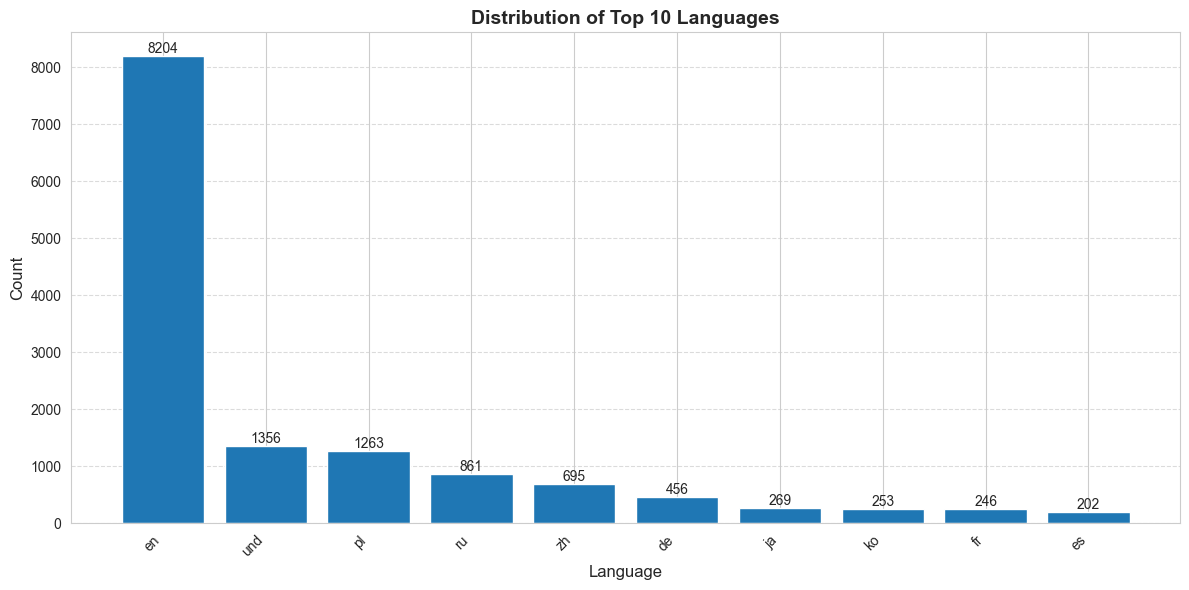

In [28]:
# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Get language distribution and sort by frequency
lang_dist = df['language'].value_counts()
top_langs = lang_dist.head(10)

# Create bar plot
bars = plt.bar(range(len(top_langs)), top_langs.values)
plt.xticks(range(len(top_langs)), top_langs.index, rotation=45, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(top_langs.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Customize the plot
plt.title('Distribution of Top 10 Languages', fontsize=14, fontweight='bold')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [25]:
# Helper functions (use modular implementations)
from modules.countTokens import countTokens as _countTokens
from modules.detectEmojis import detectEmojis as _detectEmojis
from modules.detectTables import detectTables as _detectTables
from modules.analyzeWritingStyle import analyzeWritingStyle as _analyzeWritingStyle

def count_tokens(text):
    """Count tokens using local module or tiktoken if enabled."""
    if pd.isna(text) or text == '':
        return 0
    if USE_TIKTOKEN:
        return len(ENCODING.encode(str(text)))
    return _countTokens(text)

def detect_emojis(text):
    """Detect emojis using the packaged utility."""
    if pd.isna(text) or text == '':
        return False
    return _detectEmojis(text)

def detect_tables(text):
    """Detect tables using the packaged utility."""
    if pd.isna(text) or text == '':
        return False
    return _detectTables(text)

def analyze_writing_style(text):
    """Analyze writing style using the packaged utility and normalize output keys."""
    if pd.isna(text) or text == '':
        return {'is_detailed': False, 'word_count': 0, 'sentence_count': 0, 'avg_words_per_sentence': 0}
    m = _analyzeWritingStyle(text)
    # Ensure keys exist and types are consistent
    return {
        'is_detailed': bool(m.get('is_detailed', False)),
        'word_count': int(m.get('word_count', 0)),
        'sentence_count': int(m.get('sentence_count', 0)),
        'avg_words_per_sentence': float(m.get('avg_words_per_sentence', 0.0)),
    }

print("Helper functions defined!")


Helper functions defined!


In [26]:
# Imports for module testing
from modules.countTokens import countTokens
from modules.detectEmojis import detectEmojis
from modules.detectTables import detectTables
from modules.analyzeWritingStyle import analyzeWritingStyle
print("Imported helper modules.")


Imported helper modules.


In [27]:
# Unit tests: countTokens (approximation)
assert countTokens(None) == 0
assert countTokens("") == 0
assert countTokens("abcd") == 1  # 4 chars -> 1 token
assert countTokens("abcdefgh") == 2  # 8 chars -> 2 tokens
assert countTokens("a" * 9) == 2  # floor(9/4) = 2
print("countTokens unit tests passed.")


countTokens unit tests passed.


In [28]:
# Unit tests: detectEmojis
assert detectEmojis(None) is False
assert detectEmojis("") is False
assert detectEmojis("hello") is False
assert detectEmojis("hello 😊") is True
assert detectEmojis("⚙️ settings") is True
print("detectEmojis unit tests passed.")


detectEmojis unit tests passed.


In [29]:
# Unit tests: detectTables
assert detectTables(None) is False
assert detectTables("") is False
assert detectTables("plain text") is False
assert detectTables("| col1 | col2 |\n| --- | --- |\n| a | b |") is True  # Markdown
assert detectTables("<table><tr><td>a</td></tr></table>") is True  # HTML
print("detectTables unit tests passed.")


detectTables unit tests passed.


In [30]:
# Unit tests: analyzeWritingStyle
short_text = "Brief sentence. Another short."
long_text = """This is a considerably longer example sentence that should push the
average words per sentence above the threshold, thereby indicating a more
elaborate and detailed style overall, with multiple clauses and descriptive
phrases added for good measure."""

m_empty = analyzeWritingStyle("")
assert m_empty['is_detailed'] is False and m_empty['word_count'] == 0

m_short = analyzeWritingStyle(short_text)
assert m_short['word_count'] > 0 and m_short['avg_words_per_sentence'] < 15

m_long = analyzeWritingStyle(long_text)
assert m_long['word_count'] > 50 or m_long['avg_words_per_sentence'] > 15
print("analyzeWritingStyle unit tests passed.")


analyzeWritingStyle unit tests passed.


In [31]:
# Dataset test: countTokens over user_prompt, response_a, response_b
cols = ['user_prompt', 'response_a', 'response_b']
ct_summary = {}
for c in cols:
	if c in df.columns:
		vals = df[c].apply(countTokens)
		ct_summary[c] = {
			'non_null': int(vals.notna().sum()),
			'mean': float(vals.mean()),
			'median': float(vals.median()),
			'p90': float(vals.quantile(0.90)),
			'max': int(vals.max()),
		}

print("countTokens dataset summary:")
for k, v in ct_summary.items():
	print(f"  {k} -> {v}")


countTokens dataset summary:
  user_prompt -> {'non_null': 14813, 'mean': 102.84128805778708, 'median': 19.0, 'p90': 142.0, 'max': 27572}
  response_a -> {'non_null': 14813, 'mean': 679.1697157901843, 'median': 520.0, 'p90': 1417.0, 'max': 26992}
  response_b -> {'non_null': 14813, 'mean': 680.3937757375279, 'median': 521.0, 'p90': 1412.0, 'max': 34721}


In [34]:
# Dataset test: detectEmojis over user_prompt, response_a, response_b
cols = ['user_prompt', 'response_a', 'response_b']
emoji_summary = {}
for c in cols:
	if c in df.columns:
		flags = df[c].apply(detectEmojis)
		emoji_summary[c] = {
			'true_count': int(flags.sum()),
			'rate': float(flags.mean()),
		}

print("detectEmojis dataset summary:")
for k, v in emoji_summary.items():
	print(f"  {k} -> {v}")

# Show a few examples
for c in ['response_a', 'response_b']:
	if c in df.columns:
		rows = df[df[c].apply(detectEmojis)][[c]].head(3)
		print(f"\nExamples with emojis in {c}:")
		for _, r in rows.iterrows():
			print(f"- {str(r[c])[:180].replace('\n',' ')}...")


detectEmojis dataset summary:
  user_prompt -> {'true_count': 1882, 'rate': 0.12705056369405252}
  response_a -> {'true_count': 5987, 'rate': 0.40417201107135625}
  response_b -> {'true_count': 6069, 'rate': 0.409707689191926}

Examples with emojis in response_a:
- Yes, feeling some **muscle fatigue** or a **mild ache** after exercise—especially something like walking 8,000 to 10,000 steps—can indeed be a sign that you've done **enough for th...
- 提升聚氨酯微相分离程度是优化其性能（如机械强度、弹性、耐磨性等）的关键。微相分离程度主要取决于聚合物链段的相容性和相互作用，可以通过以下方法来增强：  ### 1. **调整硬段与软段的比例**    - **增加硬段含量**：硬段（如MDI、HDI等）的极性较强，软段（如PTMG、PCL等）为非极性或弱极性。提高硬段比例会增强相分离，因为硬段与软段的相容性...
- Hmm... I'm going to take a wild guess—are you thinking *"Let’s see if ChatGPT can actually read my mind"*? 😄  Okay, your turn—give me a hint, and I’ll try again!...

Examples with emojis in response_a:
- Yes, feeling some **muscle fatigue** or a **mild ache** after exercise—especially something like walking 8,000 to 10,000 steps—can indeed be a sign that you'v

In [35]:
# Dataset test: detectTables over user_prompt, response_a, response_b
cols = ['user_prompt', 'response_a', 'response_b']
table_summary = {}
for c in cols:
	if c in df.columns:
		flags = df[c].apply(detectTables)
		table_summary[c] = {
			'true_count': int(flags.sum()),
			'rate': float(flags.mean()),
		}

print("detectTables dataset summary:")
for k, v in table_summary.items():
	print(f"  {k} -> {v}")

# Show a few examples
for c in ['response_a', 'response_b']:
	if c in df.columns:
		rows = df[df[c].apply(detectTables)][[c]].head(3)
		print(f"\nExamples with tables in {c}:")
		for _, r in rows.iterrows():
			lines = str(r[c]).split("\n")
			preview = " ".join(lines[:5])
			print(f"- {preview[:200]}...")


detectTables dataset summary:
  user_prompt -> {'true_count': 68, 'rate': 0.0045905623438871265}
  response_a -> {'true_count': 2517, 'rate': 0.16991831499358673}
  response_b -> {'true_count': 2624, 'rate': 0.17714169985823264}

Examples with tables in response_a:
- # 平价奶茶店选址对比  | 维度 | A：县城中部商圈 | B：东部省道 & 高速交叉口 | C：西部居民区（近两小学、一中学） | |---|---|---|---| | 典型客群 | 白领、逛街人群、家庭购物者 | 住院病患家属、医护人员、过路司机与旅客 | 小学/中学学生、老师、周边居民 |...
- Below is a concrete recipe for a “Safety-LOC” benchmark whose goal is:    Given any video and a set of platform policies, temporally localize every segment that violates (one or more of) those policie...
- Absolutely! While AI-powered agents (like chatbots or virtual assistants) are a popular application of AI in B2B e-commerce, there are **many other impactful uses** of AI that can enhance the web expe...

Examples with tables in response_b:
- Ob **"Aeneis"** ein gutes Prozessmanagement-Tool ist, hängt stark von den Anforderungen und dem Einsatzzweck in deinem Unterneh

In [36]:
# Dataset test: analyzeWritingStyle over user_prompt, response_a, response_b
cols = ['user_prompt', 'response_a', 'response_b']
style_summary = {}
for c in cols:
	if c in df.columns:
		metrics = df[c].apply(analyzeWritingStyle)
		mdf = pd.DataFrame(list(metrics))
		style_summary[c] = {
			'mean_word_count': float(mdf['word_count'].mean()),
			'mean_sentence_count': float(mdf['sentence_count'].mean()),
			'mean_avg_wps': float(mdf['avg_words_per_sentence'].mean()),
			'detailed_rate': float(mdf['is_detailed'].mean()),
		}

print("analyzeWritingStyle dataset summary:")
for k, v in style_summary.items():
	print(f"  {k} -> {v}")

# Show examples for response_a
if 'response_a' in df.columns:
	metrics_a = df['response_a'].apply(analyzeWritingStyle)
	mdf_a = pd.DataFrame(list(metrics_a))
	df_a = pd.concat([df[['id','response_a']], mdf_a], axis=1)
	print("\nExamples of detailed response_a:")
	for _, r in df_a[df_a['is_detailed']].head(2).iterrows():
		print(f"- id={r['id']} avg_wps={r['avg_words_per_sentence']:.1f}, words={r['word_count']}")
	print("\nExamples of general/brief response_a:")
	for _, r in df_a[~df_a['is_detailed']].head(2).iterrows():
		print(f"- id={r['id']} avg_wps={r['avg_words_per_sentence']:.1f}, words={r['word_count']}")


analyzeWritingStyle dataset summary:
  user_prompt -> {'mean_word_count': 50.998987375953554, 'mean_sentence_count': 2.658813204617566, 'mean_avg_wps': 17.422931576168054, 'detailed_rate': 0.11948963748059137}
  response_a -> {'mean_word_count': 377.42557213258624, 'mean_sentence_count': 22.62053601566192, 'mean_avg_wps': 24.385415504525987, 'detailed_rate': 0.5467494768109094}
  response_b -> {'mean_word_count': 377.1857827583879, 'mean_sentence_count': 22.810301761965842, 'mean_avg_wps': 24.445325425314728, 'detailed_rate': 0.5556605684196314}

Examples of detailed response_a:
- id=e67468c9-69b7-4b84-9ec2-27879128c4c6 avg_wps=22.6, words=339
- id=bb7d3764-a131-45a7-a2fe-bb8400717850 avg_wps=25.2, words=101

Examples of general/brief response_a:
- id=cf25ce13-799e-458d-a1fd-1321c54e104a avg_wps=6.2, words=56
- id=7ba7523e-00e3-47be-9fea-c79269e25a4b avg_wps=10.4, words=94

Examples of detailed response_a:
- id=e67468c9-69b7-4b84-9ec2-27879128c4c6 avg_wps=22.6, words=339
- id=bb7d3764-

In [37]:
# Prepare data: Focus on battles involving OpenAI models (GPT)
# Create a flag for GPT battles
df['gpt_battle'] = df['gpt_in_a'] | df['gpt_in_b']

# Filter to only GPT battles
df_gpt = df[df['gpt_battle']].copy()
print(f"Battles involving GPT models: {len(df_gpt)}")

# Determine if GPT won, lost, or tied
def get_gpt_result(row):
    """Determine if GPT won, lost, or tied"""
    if row['winner'] == 'tie':
        return 'tie'
    elif (row['winner'] == 'model_a' and row['gpt_in_a']) or (row['winner'] == 'model_b' and row['gpt_in_b']):
        return 'win'
    elif (row['winner'] == 'model_a' and row['gpt_in_b']) or (row['winner'] == 'model_b' and row['gpt_in_a']):
        return 'loss'
    else:
        return 'unknown'

df_gpt['gpt_result'] = df_gpt.apply(get_gpt_result, axis=1)

# Get the GPT response and opponent response
def get_gpt_response(row):
    """Get GPT's response"""
    if row['gpt_in_a']:
        return row['response_a']
    elif row['gpt_in_b']:
        return row['response_b']
    return None

def get_opponent_response(row):
    """Get opponent's response"""
    if row['gpt_in_a']:
        return row['response_b']
    elif row['gpt_in_b']:
        return row['response_a']
    return None

df_gpt['gpt_response'] = df_gpt.apply(get_gpt_response, axis=1)
df_gpt['opponent_response'] = df_gpt.apply(get_opponent_response, axis=1)

print(f"\nGPT Results distribution:")
print(df_gpt['gpt_result'].value_counts())


Battles involving GPT models: 14813

GPT Results distribution:
gpt_result
win        6844
loss       4114
tie        2367
unknown    1488
Name: count, dtype: int64

GPT Results distribution:
gpt_result
win        6844
loss       4114
tie        2367
unknown    1488
Name: count, dtype: int64


1. WINS AND LOSSES ANALYSIS FOR OPENAI MODELS

Overall Results:
  WIN: 6844 (46.20%)
  LOSS: 4114 (27.77%)
  TIE: 2367 (15.98%)
  UNKNOWN: 1488 (10.05%)


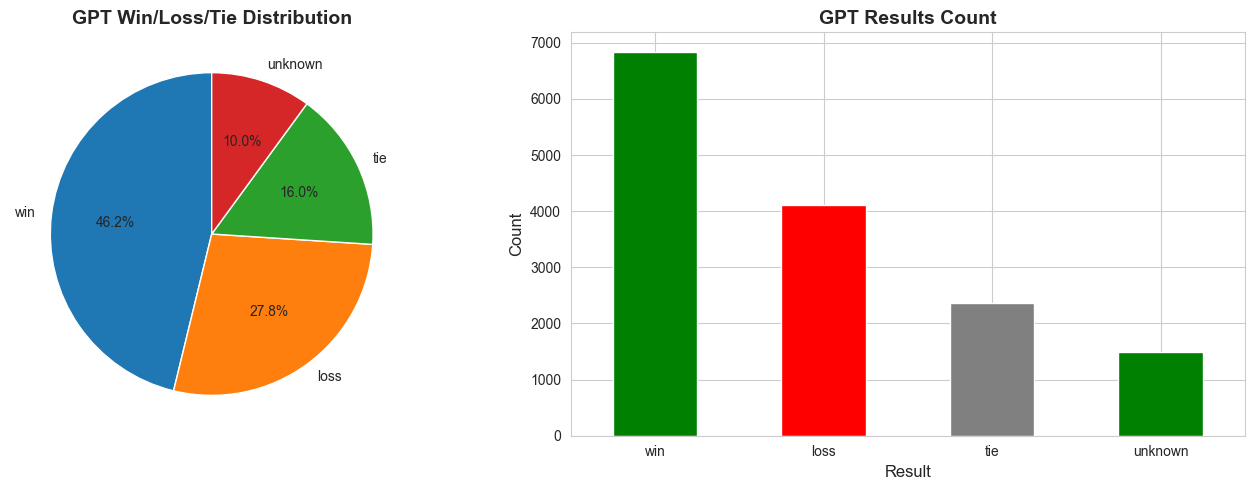

In [38]:
# 1. Analysis: Wins and Losses for OpenAI Models
# Overall win/loss distribution
print("=" * 60)
print("1. WINS AND LOSSES ANALYSIS FOR OPENAI MODELS")
print("=" * 60)

result_counts = df_gpt['gpt_result'].value_counts()
print(f"\nOverall Results:")
for result, count in result_counts.items():
    pct = (count / len(df_gpt)) * 100
    print(f"  {result.upper()}: {count} ({pct:.2f}%)")

# Visualize win/loss distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(result_counts.values, labels=result_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('GPT Win/Loss/Tie Distribution', fontsize=14, fontweight='bold')

# Bar chart
result_counts.plot(kind='bar', ax=axes[1], color=['green', 'red', 'gray'])
axes[1].set_title('GPT Results Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Result', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


2. WINS/LOSSES DISTRIBUTION BY LANGUAGE

Language Distribution in GPT Battles:
  en: 8204 (55.38%)
  und: 1356 (9.15%)
  pl: 1263 (8.53%)
  ru: 861 (5.81%)
  zh: 695 (4.69%)
  de: 456 (3.08%)
  ja: 269 (1.82%)
  ko: 253 (1.71%)
  fr: 246 (1.66%)
  es: 202 (1.36%)

Win/Loss by Language (Top 10):
gpt_result  loss  tie  unknown  win  All
language                                
<err>          1    2        1    0    4
af             0    1        0    1    2
ak             0    0        0    1    1
ar             9    9        6   16   40
be             0    0        0    1    1
bg             1    0        0    0    1
bn             4    0        0    8   12
bs             0    0        0    1    1
ca             0    0        0    3    3
co             0    0        0    3    3
crs            0    0        0    1    1


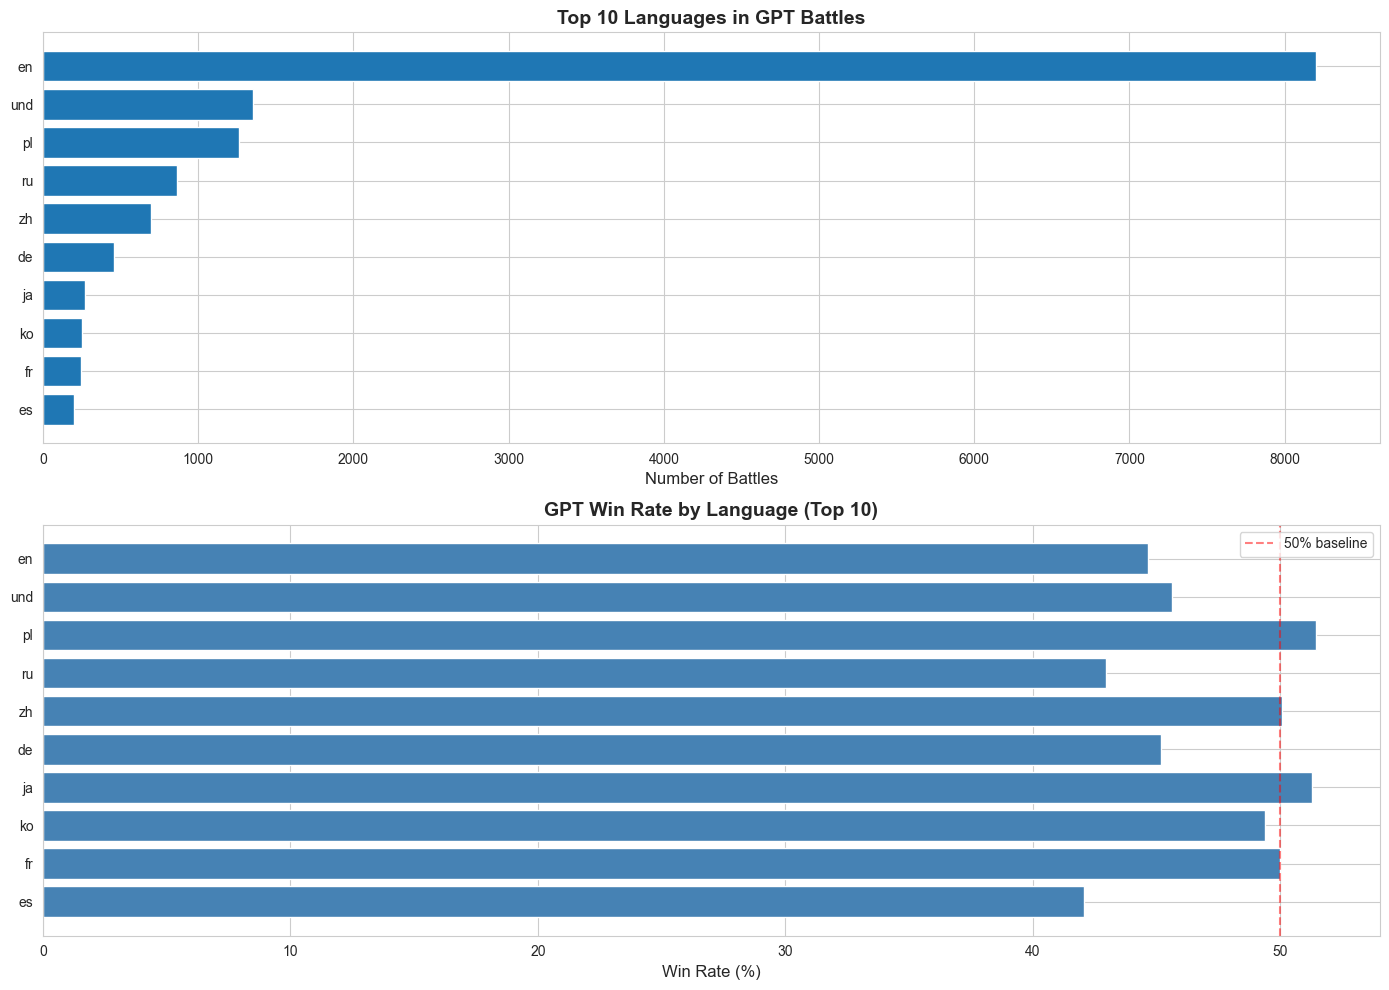

In [39]:
# 2. Analysis: Wins/Losses Distribution by Language
# Focus on English language (as per requirements)
print("=" * 60)
print("2. WINS/LOSSES DISTRIBUTION BY LANGUAGE")
print("=" * 60)

# Language distribution
lang_dist = df_gpt['language'].value_counts()
print(f"\nLanguage Distribution in GPT Battles:")
for lang, count in lang_dist.head(10).items():
    pct = (count / len(df_gpt)) * 100
    print(f"  {lang}: {count} ({pct:.2f}%)")

# Filter for English language (focus as per requirements)
df_gpt_english = df_gpt[df_gpt['language'].str.lower() == 'english'].copy()

# Win/loss by language
lang_result = pd.crosstab(df_gpt['language'], df_gpt['gpt_result'], margins=True)
print(f"\nWin/Loss by Language (Top 10):")
print(lang_result.head(11))

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top languages bar chart
top_langs = lang_dist.head(10)
axes[0].barh(range(len(top_langs)), top_langs.values)
axes[0].set_yticks(range(len(top_langs)))
axes[0].set_yticklabels(top_langs.index)
axes[0].set_xlabel('Number of Battles', fontsize=12)
axes[0].set_title('Top 10 Languages in GPT Battles', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Win rate by language (for top languages)
top_langs_list = lang_dist.head(10).index.tolist()
lang_win_rates = []
for lang in top_langs_list:
    lang_df = df_gpt[df_gpt['language'] == lang]
    if len(lang_df) > 0:
        wins = (lang_df['gpt_result'] == 'win').sum()
        total = len(lang_df)
        win_rate = (wins / total) * 100 if total > 0 else 0
        lang_win_rates.append(win_rate)
    else:
        lang_win_rates.append(0)

axes[1].barh(range(len(top_langs_list)), lang_win_rates, color='steelblue')
axes[1].set_yticks(range(len(top_langs_list)))
axes[1].set_yticklabels(top_langs_list)
axes[1].set_xlabel('Win Rate (%)', fontsize=12)
axes[1].set_title('GPT Win Rate by Language (Top 10)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1].legend()

plt.tight_layout()
plt.show()

# English-specific analysis
if len(df_gpt_english) > 0:
    print(f"\nEnglish Language Results:")
    eng_result_counts = df_gpt_english['gpt_result'].value_counts()
    for result, count in eng_result_counts.items():
        pct = (count / len(df_gpt_english)) * 100
        print(f"  {result.upper()}: {count} ({pct:.2f}%)")


3. RESPONSE LENGTH (TOKEN COUNT) IMPACT ANALYSIS
Calculating token counts...

Token Statistics by Result:
                  mean  median         std  min    max
gpt_result                                            
loss        612.210258   483.5  847.946705    1  26992
tie         603.706802   523.0  498.112593    0   3989
unknown     618.459005   465.0  932.365695    0  29523
win         680.655319   597.5  528.353968    0   7603

Mean tokens for wins: 680.66
Mean tokens for losses: 612.21
Difference: 68.45 tokens


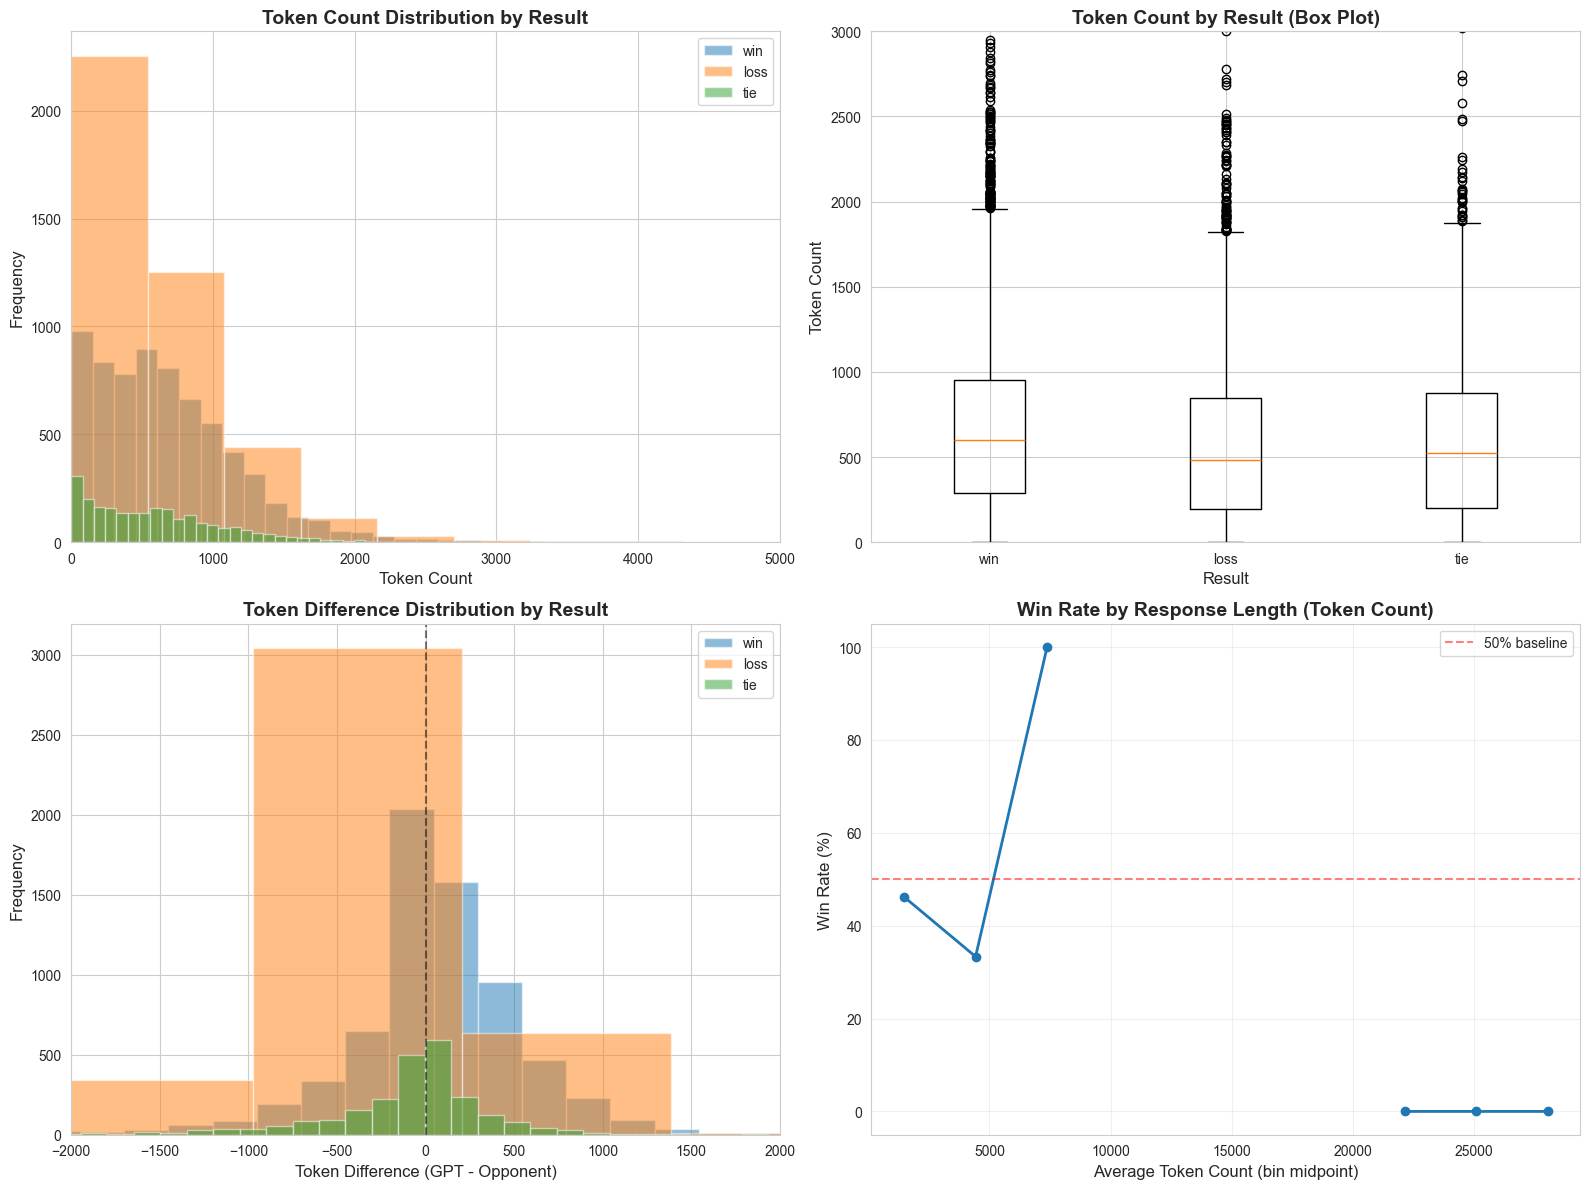


General Token Analysis:
Mean tokens across all responses: 643.10
Median tokens across all responses: 544.00
Token count range: 0 to 29523


In [40]:
# 3. Analysis: Response Length (Token Count) Impact on Wins/Losses
print("=" * 60)
print("3. RESPONSE LENGTH (TOKEN COUNT) IMPACT ANALYSIS")
print("=" * 60)

# Calculate token counts for GPT and opponent responses
print("Calculating token counts...")
df_gpt['gpt_tokens'] = df_gpt['gpt_response'].apply(count_tokens)
df_gpt['opponent_tokens'] = df_gpt['opponent_response'].apply(count_tokens)
df_gpt['token_diff'] = df_gpt['gpt_tokens'] - df_gpt['opponent_tokens']

# Statistics by result
print("\nToken Statistics by Result:")
token_stats = df_gpt.groupby('gpt_result')['gpt_tokens'].agg(['mean', 'median', 'std', 'min', 'max'])
print(token_stats)

# Compare token counts for wins vs losses
wins_tokens = df_gpt[df_gpt['gpt_result'] == 'win']['gpt_tokens']
losses_tokens = df_gpt[df_gpt['gpt_result'] == 'loss']['gpt_tokens']

print(f"\nMean tokens for wins: {wins_tokens.mean():.2f}")
print(f"Mean tokens for losses: {losses_tokens.mean():.2f}")
print(f"Difference: {wins_tokens.mean() - losses_tokens.mean():.2f} tokens")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of token counts by result
for result in ['win', 'loss', 'tie']:
    data = df_gpt[df_gpt['gpt_result'] == result]['gpt_tokens']
    if len(data) > 0:
        axes[0, 0].hist(data, alpha=0.5, label=result, bins=50)

axes[0, 0].set_xlabel('Token Count', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Token Count Distribution by Result', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 5000)  # Limit x-axis for better visibility

# Box plot
result_order = ['win', 'loss', 'tie']
data_for_box = [df_gpt[df_gpt['gpt_result'] == r]['gpt_tokens'].dropna() for r in result_order if (df_gpt['gpt_result'] == r).any()]
axes[0, 1].boxplot(data_for_box, labels=[r for r in result_order if (df_gpt['gpt_result'] == r).any()])
axes[0, 1].set_ylabel('Token Count', fontsize=12)
axes[0, 1].set_xlabel('Result', fontsize=12)
axes[0, 1].set_title('Token Count by Result (Box Plot)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylim(0, 3000)

# Token difference (GPT - Opponent) by result
for result in ['win', 'loss', 'tie']:
    data = df_gpt[df_gpt['gpt_result'] == result]['token_diff']
    if len(data) > 0:
        axes[1, 0].hist(data, alpha=0.5, label=result, bins=50)

axes[1, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Token Difference (GPT - Opponent)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Token Difference Distribution by Result', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_xlim(-2000, 2000)

# Win rate by token count bins
df_gpt['token_bin'] = pd.cut(df_gpt['gpt_tokens'], bins=10)
win_rate_by_tokens = df_gpt.groupby('token_bin')['gpt_result'].apply(
    lambda x: (x == 'win').sum() / len(x) * 100
).reset_index()
win_rate_by_tokens['token_bin_mid'] = win_rate_by_tokens['token_bin'].apply(lambda x: x.mid)

axes[1, 1].plot(win_rate_by_tokens['token_bin_mid'], win_rate_by_tokens['gpt_result'], marker='o', linewidth=2)
axes[1, 1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1, 1].set_xlabel('Average Token Count (bin midpoint)', fontsize=12)
axes[1, 1].set_ylabel('Win Rate (%)', fontsize=12)
axes[1, 1].set_title('Win Rate by Response Length (Token Count)', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# General token analysis (not specific to English)
print("\nGeneral Token Analysis:")
print(f"Mean tokens across all responses: {df_gpt['gpt_tokens'].mean():.2f}")
print(f"Median tokens across all responses: {df_gpt['gpt_tokens'].median():.2f}")
print(f"Token count range: {df_gpt['gpt_tokens'].min():.0f} to {df_gpt['gpt_tokens'].max():.0f}")


4. EMOJI AND TABLE USAGE ANALYSIS (VISUALIZATION STYLE)

GPT Emoji Usage: 8231 (55.57%)
GPT Table Usage: 4164 (28.11%)
Opponent Emoji Usage: 3825 (25.82%)
Opponent Table Usage: 977 (6.60%)

Emoji Usage by Result:
gpt_has_emoji  False  True    All
gpt_result                       
loss            2069  2045   4114
tie             1098  1269   2367
unknown          739   749   1488
win             2676  4168   6844
All             6582  8231  14813

Table Usage by Result:
gpt_has_table  False  True    All
gpt_result                       
loss            3196   918   4114
tie             1733   634   2367
unknown         1185   303   1488
win             4535  2309   6844
All            10649  4164  14813

Win rate WITH emojis: 50.64%
Win rate WITHOUT emojis: 40.66%
Win rate WITH tables: 55.45%
Win rate WITHOUT tables: 42.59%

GPT Emoji Usage: 8231 (55.57%)
GPT Table Usage: 4164 (28.11%)
Opponent Emoji Usage: 3825 (25.82%)
Opponent Table Usage: 977 (6.60%)

Emoji Usage by Result:
gpt_has

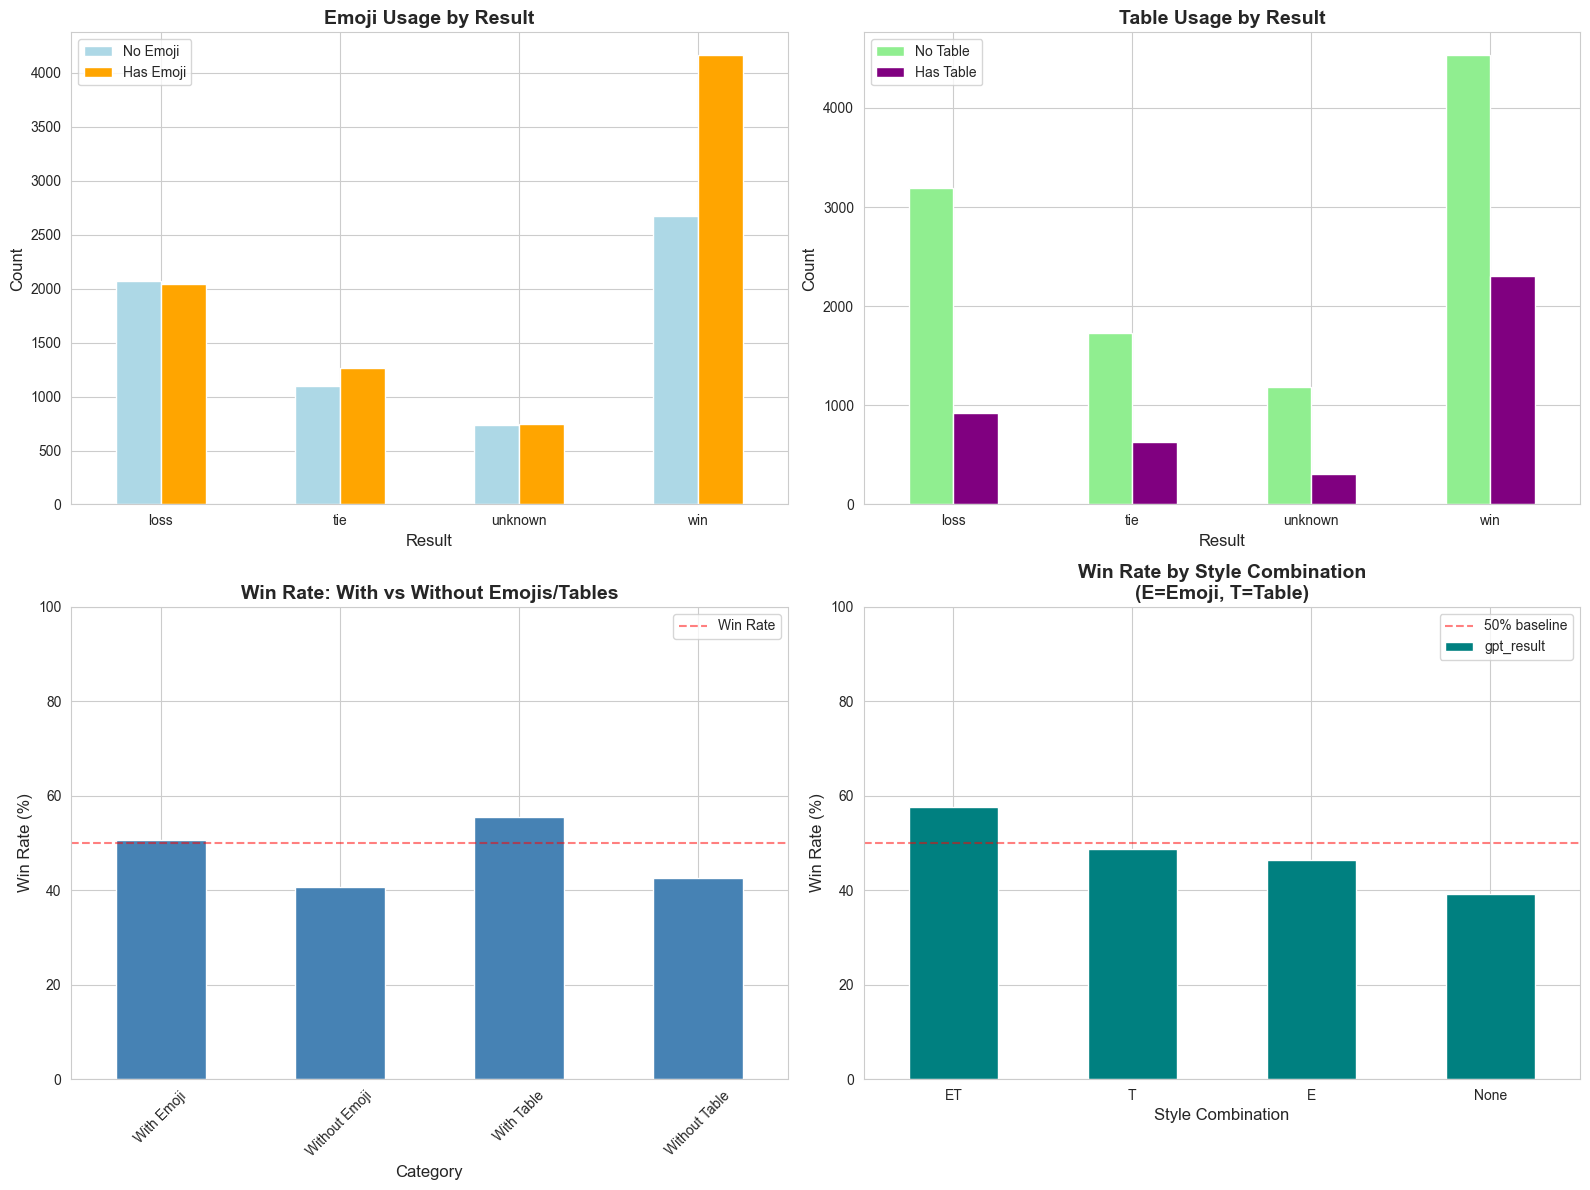

In [41]:
# 4. Analysis: Emojis and Tables in Responses (Visualization Style)
print("=" * 60)
print("4. EMOJI AND TABLE USAGE ANALYSIS (VISUALIZATION STYLE)")
print("=" * 60)

# Detect emojis and tables in GPT responses
df_gpt['gpt_has_emoji'] = df_gpt['gpt_response'].apply(detect_emojis)
df_gpt['gpt_has_table'] = df_gpt['gpt_response'].apply(detect_tables)
df_gpt['opponent_has_emoji'] = df_gpt['opponent_response'].apply(detect_emojis)
df_gpt['opponent_has_table'] = df_gpt['opponent_response'].apply(detect_tables)

# Overall usage
print(f"\nGPT Emoji Usage: {df_gpt['gpt_has_emoji'].sum()} ({df_gpt['gpt_has_emoji'].mean()*100:.2f}%)")
print(f"GPT Table Usage: {df_gpt['gpt_has_table'].sum()} ({df_gpt['gpt_has_table'].mean()*100:.2f}%)")
print(f"Opponent Emoji Usage: {df_gpt['opponent_has_emoji'].sum()} ({df_gpt['opponent_has_emoji'].mean()*100:.2f}%)")
print(f"Opponent Table Usage: {df_gpt['opponent_has_table'].sum()} ({df_gpt['opponent_has_table'].mean()*100:.2f}%)")

# Emoji usage by result
print("\nEmoji Usage by Result:")
emoji_by_result = pd.crosstab(df_gpt['gpt_result'], df_gpt['gpt_has_emoji'], margins=True)
print(emoji_by_result)

# Table usage by result
print("\nTable Usage by Result:")
table_by_result = pd.crosstab(df_gpt['gpt_result'], df_gpt['gpt_has_table'], margins=True)
print(table_by_result)

# Win rate with/without emojis
win_rate_with_emoji = (df_gpt[df_gpt['gpt_has_emoji']]['gpt_result'] == 'win').mean() * 100
win_rate_without_emoji = (df_gpt[~df_gpt['gpt_has_emoji']]['gpt_result'] == 'win').mean() * 100
print(f"\nWin rate WITH emojis: {win_rate_with_emoji:.2f}%")
print(f"Win rate WITHOUT emojis: {win_rate_without_emoji:.2f}%")

# Win rate with/without tables
win_rate_with_table = (df_gpt[df_gpt['gpt_has_table']]['gpt_result'] == 'win').mean() * 100
win_rate_without_table = (df_gpt[~df_gpt['gpt_has_table']]['gpt_result'] == 'win').mean() * 100
print(f"Win rate WITH tables: {win_rate_with_table:.2f}%")
print(f"Win rate WITHOUT tables: {win_rate_without_table:.2f}%")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Emoji usage by result
emoji_crosstab = pd.crosstab(df_gpt['gpt_result'], df_gpt['gpt_has_emoji'])
emoji_crosstab.plot(kind='bar', ax=axes[0, 0], color=['lightblue', 'orange'])
axes[0, 0].set_title('Emoji Usage by Result', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Result', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].legend(['No Emoji', 'Has Emoji'])
axes[0, 0].tick_params(axis='x', rotation=0)

# Table usage by result
table_crosstab = pd.crosstab(df_gpt['gpt_result'], df_gpt['gpt_has_table'])
table_crosstab.plot(kind='bar', ax=axes[0, 1], color=['lightgreen', 'purple'])
axes[0, 1].set_title('Table Usage by Result', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Result', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].legend(['No Table', 'Has Table'])
axes[0, 1].tick_params(axis='x', rotation=0)

# Win rate comparison
win_rates = pd.DataFrame({
    'With Emoji': [win_rate_with_emoji],
    'Without Emoji': [win_rate_without_emoji],
    'With Table': [win_rate_with_table],
    'Without Table': [win_rate_without_table]
})
win_rates.T.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'coral'])
axes[1, 0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1, 0].set_title('Win Rate: With vs Without Emojis/Tables', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Win Rate (%)', fontsize=12)
axes[1, 0].set_xlabel('Category', fontsize=12)
axes[1, 0].legend(['Win Rate'])
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0, 100)

# Combination analysis
df_gpt['style_combo'] = df_gpt.apply(
    lambda row: f"{'E' if row['gpt_has_emoji'] else ''}{'T' if row['gpt_has_table'] else ''}" or 'None',
    axis=1
)
combo_win_rates = df_gpt.groupby('style_combo')['gpt_result'].apply(
    lambda x: (x == 'win').sum() / len(x) * 100
).sort_values(ascending=False)

combo_win_rates.plot(kind='bar', ax=axes[1, 1], color='teal')
axes[1, 1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1, 1].set_title('Win Rate by Style Combination\n(E=Emoji, T=Table)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Win Rate (%)', fontsize=12)
axes[1, 1].set_xlabel('Style Combination', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.show()


5. WRITING STYLE ANALYSIS (GENERAL VS DETAILED)
Analyzing writing styles...

Writing Style Statistics by Result:
           gpt_word_count        gpt_avg_words_per_sentence             \
                     mean median                       mean     median   
gpt_result                                                               
loss           349.512397  285.0                  23.575877  16.234432   
tie            347.429658  303.0                  21.655505  16.300000   
unknown        347.190860  274.5                  26.200944  17.803226   
win            387.510228  351.0                  22.957367  16.492857   

           gpt_is_detailed  
                      mean  
gpt_result                  
loss              0.542538  
tie               0.536122  
unknown           0.598790  
win               0.562683  

Detailed Writing Usage:
gpt_is_detailed  False  True    All
gpt_result                         
loss              1882  2232   4114
tie               1098  1269   2

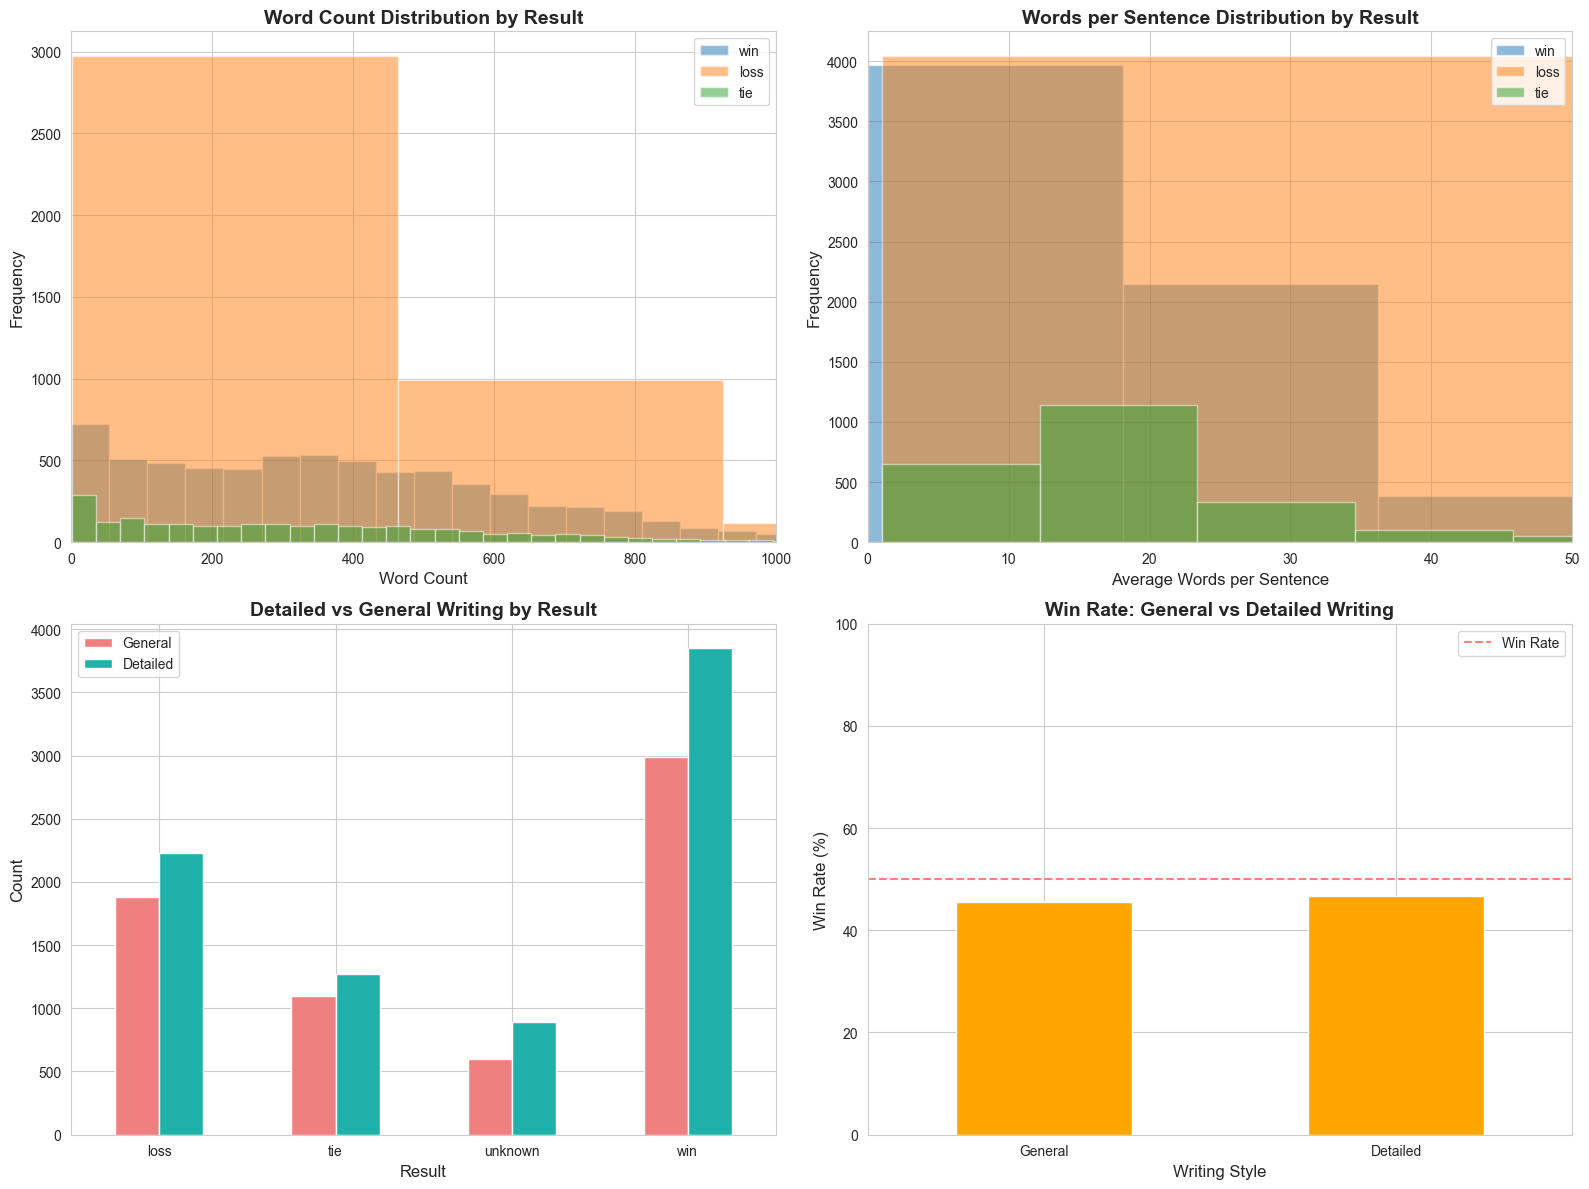

In [42]:
# 5. Analysis: Writing Style (General vs Detailed)
print("=" * 60)
print("5. WRITING STYLE ANALYSIS (GENERAL VS DETAILED)")
print("=" * 60)

# Analyze writing style for GPT and opponent responses
print("Analyzing writing styles...")
gpt_style = df_gpt['gpt_response'].apply(analyze_writing_style)
opponent_style = df_gpt['opponent_response'].apply(analyze_writing_style)

# Extract style features
df_gpt['gpt_is_detailed'] = gpt_style.apply(lambda x: x['is_detailed'])
df_gpt['gpt_word_count'] = gpt_style.apply(lambda x: x['word_count'])
df_gpt['gpt_sentence_count'] = gpt_style.apply(lambda x: x['sentence_count'])
df_gpt['gpt_avg_words_per_sentence'] = gpt_style.apply(lambda x: x['avg_words_per_sentence'])

df_gpt['opponent_is_detailed'] = opponent_style.apply(lambda x: x['is_detailed'])
df_gpt['opponent_word_count'] = opponent_style.apply(lambda x: x['word_count'])
df_gpt['opponent_avg_words_per_sentence'] = opponent_style.apply(lambda x: x['avg_words_per_sentence'])

# Statistics
print("\nWriting Style Statistics by Result:")
style_stats = df_gpt.groupby('gpt_result').agg({
    'gpt_word_count': ['mean', 'median'],
    'gpt_avg_words_per_sentence': ['mean', 'median'],
    'gpt_is_detailed': 'mean'
})
print(style_stats)

# Detailed vs General writing
print("\nDetailed Writing Usage:")
detailed_by_result = pd.crosstab(df_gpt['gpt_result'], df_gpt['gpt_is_detailed'], margins=True)
print(detailed_by_result)

# Win rate for detailed vs general
win_rate_detailed = (df_gpt[df_gpt['gpt_is_detailed']]['gpt_result'] == 'win').mean() * 100
win_rate_general = (df_gpt[~df_gpt['gpt_is_detailed']]['gpt_result'] == 'win').mean() * 100
print(f"\nWin rate with DETAILED writing: {win_rate_detailed:.2f}%")
print(f"Win rate with GENERAL writing: {win_rate_general:.2f}%")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Word count distribution by result
for result in ['win', 'loss', 'tie']:
    data = df_gpt[df_gpt['gpt_result'] == result]['gpt_word_count']
    if len(data) > 0:
        axes[0, 0].hist(data, alpha=0.5, label=result, bins=50)

axes[0, 0].set_xlabel('Word Count', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Word Count Distribution by Result', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 1000)

# Average words per sentence by result
for result in ['win', 'loss', 'tie']:
    data = df_gpt[df_gpt['gpt_result'] == result]['gpt_avg_words_per_sentence']
    if len(data) > 0:
        axes[0, 1].hist(data, alpha=0.5, label=result, bins=50)

axes[0, 1].set_xlabel('Average Words per Sentence', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Words per Sentence Distribution by Result', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 50)

# Detailed vs General writing
detailed_crosstab = pd.crosstab(df_gpt['gpt_result'], df_gpt['gpt_is_detailed'])
detailed_crosstab.plot(kind='bar', ax=axes[1, 0], color=['lightcoral', 'lightseagreen'])
axes[1, 0].set_title('Detailed vs General Writing by Result', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Result', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].legend(['General', 'Detailed'])
axes[1, 0].tick_params(axis='x', rotation=0)

# Win rate by writing style
win_rates_style = pd.DataFrame({
    'General': [win_rate_general],
    'Detailed': [win_rate_detailed]
})
win_rates_style.T.plot(kind='bar', ax=axes[1, 1], color=['orange', 'green'])
axes[1, 1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1, 1].set_title('Win Rate: General vs Detailed Writing', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Win Rate (%)', fontsize=12)
axes[1, 1].set_xlabel('Writing Style', fontsize=12)
axes[1, 1].legend(['Win Rate'])
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
# Summary and Key Findings
print("=" * 60)
print("SUMMARY OF KEY FINDINGS")
print("=" * 60)

print("\n1. OVERALL PERFORMANCE:")
overall_win_rate = (df_gpt['gpt_result'] == 'win').mean() * 100
overall_loss_rate = (df_gpt['gpt_result'] == 'loss').mean() * 100
print(f"   Win Rate: {overall_win_rate:.2f}%")
print(f"   Loss Rate: {overall_loss_rate:.2f}%")

print("\n2. RESPONSE LENGTH IMPACT:")
wins_tokens_avg = df_gpt[df_gpt['gpt_result'] == 'win']['gpt_tokens'].mean()
losses_tokens_avg = df_gpt[df_gpt['gpt_result'] == 'loss']['gpt_tokens'].mean()
print(f"   Average tokens in wins: {wins_tokens_avg:.2f}")
print(f"   Average tokens in losses: {losses_tokens_avg:.2f}")
print(f"   Difference: {wins_tokens_avg - losses_tokens_avg:.2f} tokens")

print("\n3. VISUALIZATION STYLE (Emojis & Tables):")
emoji_win_rate = (df_gpt[df_gpt['gpt_has_emoji']]['gpt_result'] == 'win').mean() * 100
no_emoji_win_rate = (df_gpt[~df_gpt['gpt_has_emoji']]['gpt_result'] == 'win').mean() * 100
table_win_rate = (df_gpt[df_gpt['gpt_has_table']]['gpt_result'] == 'win').mean() * 100
no_table_win_rate = (df_gpt[~df_gpt['gpt_has_table']]['gpt_result'] == 'win').mean() * 100
print(f"   Win rate WITH emojis: {emoji_win_rate:.2f}%")
print(f"   Win rate WITHOUT emojis: {no_emoji_win_rate:.2f}%")
print(f"   Win rate WITH tables: {table_win_rate:.2f}%")
print(f"   Win rate WITHOUT tables: {no_table_win_rate:.2f}%")

print("\n4. WRITING STYLE (Detailed vs General):")
detailed_win_rate = (df_gpt[df_gpt['gpt_is_detailed']]['gpt_result'] == 'win').mean() * 100
general_win_rate = (df_gpt[~df_gpt['gpt_is_detailed']]['gpt_result'] == 'win').mean() * 100
print(f"   Win rate with DETAILED writing: {detailed_win_rate:.2f}%")
print(f"   Win rate with GENERAL writing: {general_win_rate:.2f}%")

print("\n5. FACTORS IN LOSSES:")
df_losses = df_gpt[df_gpt['gpt_result'] == 'loss']
print(f"   Total losses analyzed: {len(df_losses)}")
print(f"   Most common language in losses: {df_losses['language'].mode().iloc[0] if len(df_losses['language'].mode()) > 0 else 'N/A'}")

print("\n" + "=" * 60)
print("EDA Analysis Complete!")
print("=" * 60)

SUMMARY OF KEY FINDINGS

1. OVERALL PERFORMANCE:
   Win Rate: 46.20%
   Loss Rate: 27.77%

3. RESPONSE LENGTH IMPACT:
   Average tokens in wins: 680.66
   Average tokens in losses: 612.21
   Difference: 68.45 tokens

4. VISUALIZATION STYLE (Emojis & Tables):
   Win rate WITH emojis: 50.64%
   Win rate WITHOUT emojis: 40.66%
   Win rate WITH tables: 55.45%
   Win rate WITHOUT tables: 42.59%

5. WRITING STYLE (Detailed vs General):
   Win rate with DETAILED writing: 46.72%
   Win rate with GENERAL writing: 45.56%

6. FACTORS IN LOSSES:
   Total losses analyzed: 4114
   Most common language in losses: en

EDA Analysis Complete!


* English heavily dominates the dataset, accounting for the largest share of samples. GPT’s win rates are generally consistent across languages, stabilizing near 50%, with minor underperformance in English and Polish.
* Outcome distribution indicates 46% wins, 28% losses, and the rest ties or unknown. GPT performs optimally with medium-length responses, while excessively long outputs tend to correlate with lower win rates.
* Structural and stylistic factors have measurable impact. The use of tables and emojis is associated with higher win frequencies, suggesting that clarity and visual organization improve model evaluations.
* Writing style—whether general or detailed—has minimal effect compared to structure. Effective responses balance information depth with concise presentation.

**Word of Wisdom:**
As a data professional, the insight is clear: performance improves through optimization, not expansion. Whether in analytics or communication, precision, structure, and relevance drive outcomes more than volume.